<a href="https://colab.research.google.com/github/IdrisJunaidAI/ITAI_ML_FirstRepo_IdrisJunaid/blob/main/L10_IdrisOJunaid_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 10 Lab: Unsupervised Learning

**Student:** Idris Junaid  
**Course:** ITAI 1371  
**Lab:** L10 Unsupervised Learning

## Objective

The objective of this lab is to understand and apply two common unsupervised learning techniques:

1. **K Means Clustering** for discovering natural groups in data.
2. **Principal Component Analysis, or PCA,** for reducing the number of dimensions while preserving most of the information.

In this lab, I complete the required code, interpret the model outputs, answer the knowledge check questions, and provide an embedded reflection.

## Part 1: Supervised Learning Compared with Unsupervised Learning

In supervised learning, the training data includes both the features, represented by **X**, and the correct target values, represented by **y**. The model learns a relationship between the inputs and the known outputs.

In unsupervised learning, the data contains features but no target labels. The algorithm explores the data to discover hidden patterns or structure.

Two major types of unsupervised learning are:

1. **Clustering:** Automatically grouping similar observations.
2. **Dimensionality reduction:** Compressing the feature space while preserving as much useful information as possible.

## Part 2: K Means Clustering

K Means divides a dataset into a predefined number of clusters, represented by **k**. It begins with cluster centroids, assigns each observation to its nearest centroid, updates each centroid to the mean position of its assigned observations, and repeats the process until the solution stabilizes.

For this section, a synthetic dataset represents customer spending behavior. Because the data is generated with four centers, it should contain four natural groups.

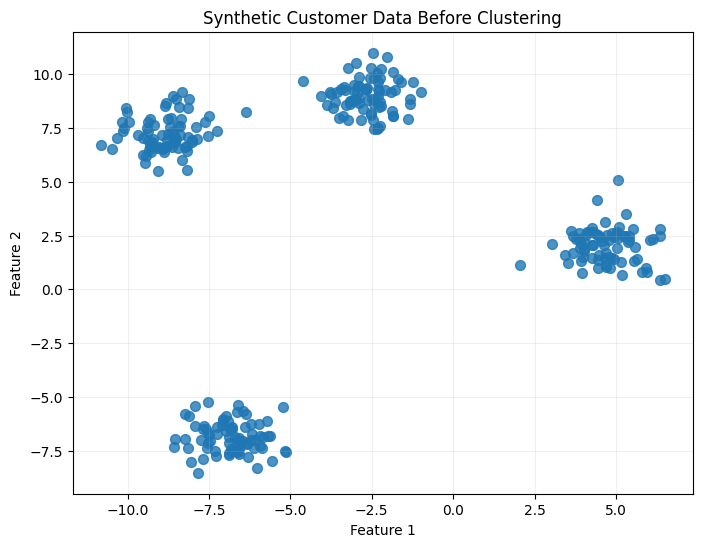

Dataset shape: (300, 2)
The clustering model receives only X, not the generated labels.


In [1]:
# Import the libraries required for data generation, analysis, and visualization.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, load_iris
from sklearn.decomposition import PCA

# Generate a synthetic dataset with four underlying groups.
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# Display the original unlabeled feature space.
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.8)
plt.title("Synthetic Customer Data Before Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.2)
plt.show()

print("Dataset shape:", X.shape)
print("The clustering model receives only X, not the generated labels.")

### Task 1: Find the Optimal Number of Clusters with the Elbow Method

The elbow method compares K Means inertia across several values of **k**. Inertia is the sum of squared distances between every observation and the centroid of its assigned cluster. Inertia always decreases as more clusters are added, so the goal is to find the point where the improvement begins to slow substantially.

,Number of Clusters (k),Inertia
0,1,19780.25
1,2,9211.21
2,3,1919.36
3,4,362.47
4,5,329.27
5,6,294.61
6,7,261.56
7,8,232.01
8,9,209.10
9,10,188.72


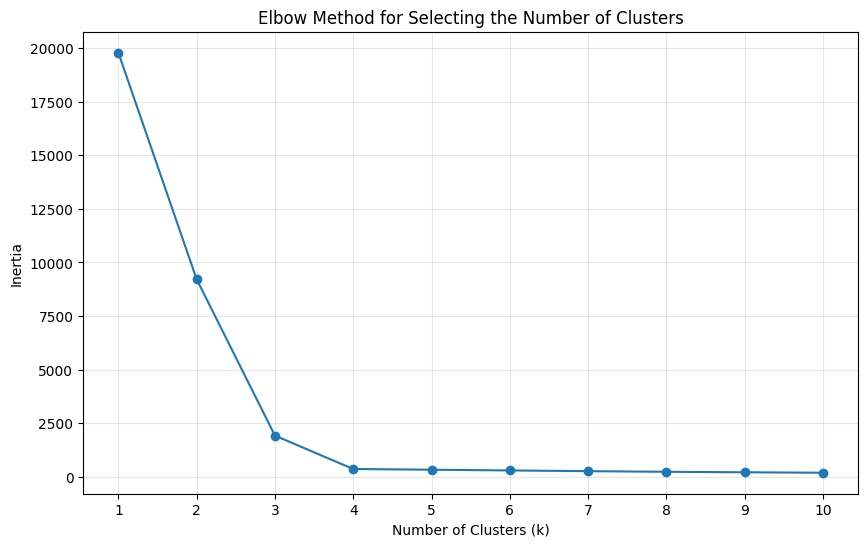

In [2]:
# Store the inertia produced by each candidate number of clusters.
inertia = []

# Fit K Means models for k values from 1 through 10.
for k in range(1, 11):
    kmeans_candidate = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_candidate.fit(X)
    inertia.append(kmeans_candidate.inertia_)

# Present the values in a table so the numerical pattern is visible.
elbow_results = pd.DataFrame({
    "Number of Clusters (k)": range(1, 11),
    "Inertia": inertia
})
display(elbow_results.round(2))

# Plot inertia against k to identify the elbow.
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker="o")
plt.xticks(range(1, 11))
plt.title("Elbow Method for Selecting the Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

#### Task 1 Interpretation

The curve drops sharply from **k = 1** through **k = 4** and then begins to flatten. This change in slope creates an elbow at approximately **k = 4**. Therefore, four clusters provide a strong balance between representing the natural structure of the data and avoiding unnecessary model complexity.

### Task 2: Perform K Means Clustering and Visualize the Results

Based on the elbow plot, the final K Means model will use four clusters. The assigned cluster labels will control the point colors, and the centroids will be displayed with large X markers.

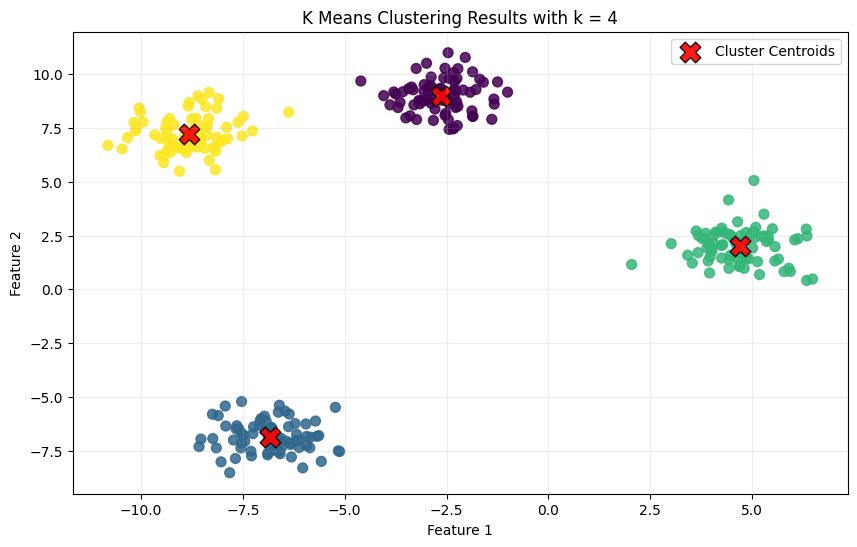

,Cluster,Number of Observations
0,0,75
1,1,75
2,2,75
3,3,75


Final model inertia: 362.47

Cluster centroids:


,Feature 1,Feature 2
0,-2.637,8.986
1,-6.842,-6.840
2,4.703,2.028
3,-8.833,7.218


In [3]:
# Create and fit the final K Means model using the selected value of k.
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
kmeans.fit(X)

# Retrieve the learned cluster labels and centroid coordinates.
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Display the clustered data and learned centroids.
plt.figure(figsize=(10, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=50,
    cmap="viridis",
    alpha=0.85
)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=220,
    alpha=0.9,
    marker="X",
    edgecolors="black",
    label="Cluster Centroids"
)
plt.title("K Means Clustering Results with k = 4")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Summarize the number of observations assigned to each cluster.
cluster_counts = (
    pd.Series(labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Number of Observations")
)
display(cluster_counts)

print("Final model inertia:", round(kmeans.inertia_, 2))
print("\nCluster centroids:")
display(pd.DataFrame(centers, columns=["Feature 1", "Feature 2"]).round(3))

#### Task 2 Interpretation

The visualization shows four compact and clearly separated groups. Each red centroid lies near the center of its assigned observations, which indicates that the iterative assignment and update process converged appropriately. The cluster labels are arbitrary identifiers, so cluster 0 is not inherently better or more important than cluster 1, cluster 2, or cluster 3. In a real customer segmentation problem, the next step would be to examine the average characteristics of each cluster and give each segment a meaningful business name.

## Part 3: Principal Component Analysis

PCA transforms correlated original features into new, uncorrelated principal components. The components are ranked by the amount of variance they explain. Keeping the first few components can make a dataset easier to visualize and process while preserving most of its structure.

The Iris dataset contains four numerical features. The goal is to reduce those four features to two principal components and visualize the observations in a two dimensional space.

### Task 3: Apply PCA to the Iris Dataset

Explained variance by component: [0.92461872 0.05306648]
Variance explained by Principal Component 1: 92.46%
Variance explained by Principal Component 2: 5.31%
Total variance explained by two components: 97.77%


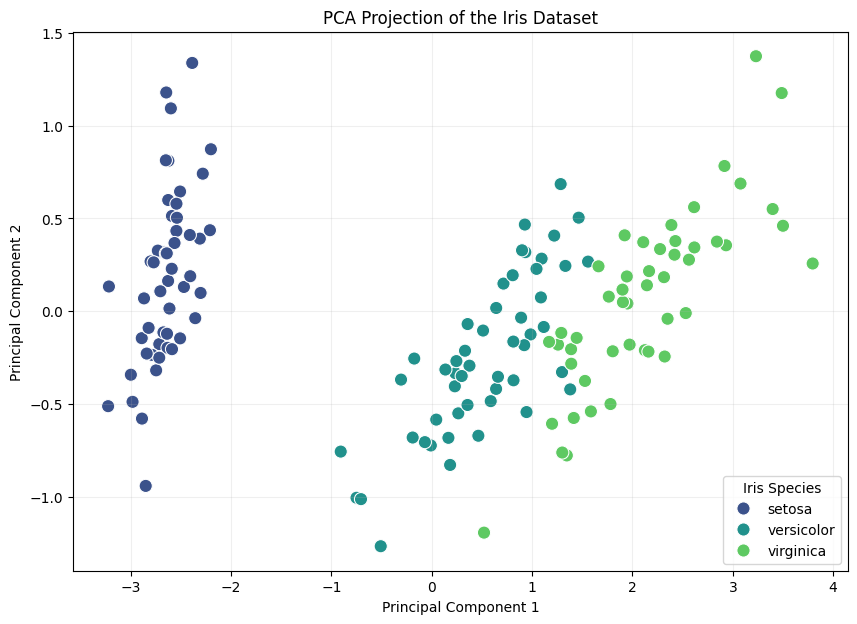

,Principal Component 1,Principal Component 2,Species
0,-2.684126,0.319397,setosa
1,-2.714142,-0.177001,setosa
2,-2.888991,-0.144949,setosa
3,-2.745343,-0.318299,setosa
4,-2.728717,0.326755,setosa


In [4]:
# Load the Iris dataset.
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Create a PCA transformer that retains two principal components.
pca = PCA(n_components=2)

# Learn the principal directions and transform the four original features.
X_pca = pca.fit_transform(X_iris)

# Report how much variance each retained component explains.
explained_variance = pca.explained_variance_ratio_
print("Explained variance by component:", explained_variance)
print(f"Variance explained by Principal Component 1: {explained_variance[0]:.2%}")
print(f"Variance explained by Principal Component 2: {explained_variance[1]:.2%}")
print(f"Total variance explained by two components: {explained_variance.sum():.2%}")

# Organize the PCA coordinates and readable species labels for plotting.
pca_df = pd.DataFrame(
    X_pca,
    columns=["Principal Component 1", "Principal Component 2"]
)
pca_df["Species"] = pd.Categorical.from_codes(
    y_iris,
    categories=iris.target_names
)

# Plot the reduced two dimensional representation.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Species",
    palette="viridis",
    s=90
)
plt.title("PCA Projection of the Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.2)
plt.legend(title="Iris Species")
plt.show()

# Display the first five transformed observations.
display(pca_df.head())

#### Task 3 Interpretation

The first two principal components preserve approximately **97.77 percent** of the total variance in the four original Iris features. The two dimensional projection therefore retains nearly all of the dataset's major structure. The setosa observations are clearly separated, while versicolor and virginica have some overlap. This indicates that two components are highly informative for visualization, although the reduction does not create perfectly separated classes.

## Knowledge Check

### 1. **What is the fundamental difference between supervised and unsupervised learning?**

Supervised learning uses labeled examples that include both input features and known target values. Its purpose is to learn a mapping that can predict the target for new observations. Unsupervised learning does not receive target labels. Instead, it searches the available features for patterns such as clusters, lower dimensional structure, or unusual observations.

### 2. **In the K-Means elbow plot, why don't we just choose the largest possible `k` to get the lowest inertia?**

Inertia decreases whenever the number of clusters increases because each point can be assigned to a closer centroid. Choosing the largest possible value of **k** could therefore produce a very low inertia, but it may divide meaningful groups into many small and unhelpful clusters. In the extreme case where every point has its own cluster, inertia would be zero, but the result would not summarize the data. The elbow method selects a smaller value where additional clusters produce only limited improvement, which balances fit and interpretability.

### 3. **In the PCA results, the first two principal components explained over 95% of the variance. What does this tell you about the original 4-dimensional Iris dataset?**

It indicates that most of the information represented by the four original features lies along approximately two dominant directions. The original features contain substantial shared or correlated structure, so four separate dimensions are not necessary to preserve most of the dataset's variation. Reducing the data to two principal components loses only a small percentage of the total variance. This makes a two dimensional visualization useful, although the principal components are combinations of the original measurements rather than direct replacements with the same interpretation.

## Reflection

### Main insight

My main insight from this lab is that unsupervised learning can reveal structure even when no correct answers are supplied to the model. K Means discovered the four synthetic groups using only the feature coordinates, while PCA reorganized four Iris features into two informative dimensions.

### Challenge and solution

The most important judgment required in K-Means was selecting the number of clusters. Inertia alone was not enough because it continued to decrease as **k** increased. I used the elbow in the plotted curve to identify the point where the benefit of adding clusters became much smaller, which supported choosing **k = 4**.

### Connection between the techniques

K-Means and PCA solve different problems but can complement each other. PCA can reduce noise and compress a high dimensional dataset before clustering, while K-Means can then identify groups in the reduced feature space. PCA can also make those groups easier to visualize in two or three dimensions.

### Practical takeaway

I learned that results from unsupervised learning require interpretation rather than automatic acceptance. Cluster numbers do not have built in meanings, and principal components are mathematical combinations of features. A responsible analysis must examine the cluster characteristics, the explained variance, the visualization, and the real world context before drawing conclusions.